# More complete example
## VeloxChem--Density matrix renormalization group (DMRG)

## Background

For a bipartite (two-part) system $A$ and $B$, e.g., two spins on a lattice, the general state can be written,
$$ \sum_{n_1 n_2} \Psi^{n_1 n_2} \ket{n_1 n_2}. $$
If the wavefunction amplitude factorizes:
$$ \Psi^{n_1 n_2} = A^{n_1}A^{n_2}, $$
we have the characteristic of a classical state in that a measurement of one part exerts no influence on the other, i.e., they can be done independently. If the amplitude doesn't factorize, there is instead some entanglement, but the amplitudes can nevertheless be written as a *sum* of such products
$$ \Psi^{n_1 n_2} = \sum_i A^{n_1}_i {\vphantom{A}}_i A^{n_2}. $$
Which is basically a matrix factorization, for a state to have low entanglement it means there are *few* such terms in the sum. It is for low-entanglement states that DMRG is efficient.

This is the basis for the matrix product state (MPS), which is the wavefunction ansatz used in DMRG. In the case of molecules, one maps the 3D molecular orbitals onto a lattice of sites, so that each site is represented by an orbital. Through the DMRG algorithm one can form well-defined local, effective Hamiltonians and solve, variationally, for the ground state site-by-site, by sweeping back and forth through the chain. The order of the chain is arbitrary, but for effectiveness one wants to put entangled orbitals close together.

For an arbitrary number of sites the MPS is written
$$ \displaystyle \sum_{\{ \sigma \}} \Psi^{\sigma_1 \sigma_2 ... \sigma_n} \ket{\sigma_1 \sigma_2 ... \sigma_n} = \sum_{ \{ \sigma \}, \{ \alpha \} } A^{\sigma_1}_{1 \alpha_1} A^{\sigma_2}_{\alpha_1 \alpha_2} ... A^{\sigma_n}_{\alpha_{n-1} 1} \ket{\sigma_1 \sigma_2 ... \sigma_n}, $$
in an analogous fashion one can define matrix product operators (MPOs).

The DMRG algorithm is equivalent to imaginary time propagation, which is just replacing $i$ in $\ket{\Psi (t)} = e^{-i H \delta t} \ket{\Psi (0)}$ by 1. Propagating in the imaginary time can be thought of as cooling down the system, i.e., going towards the ground state, or in other words, projects onto the ground state for long (imaginary) time.

# Electronic Hamiltonian
$$ \hat{H}_{\text{el}} = \sum_{\sigma, ij} t_{ij} \hat{c}^\dagger_{i, \sigma} \hat{c}^{\vphantom{\dagger}}_{j, \sigma} + \frac{1}{2} \sum_{\sigma \sigma' ijkl} V_{ijkl} \hat{c}^\dagger_{i, \sigma} \hat{c}^\dagger_{k, \sigma'} \hat{c}^{\vphantom{\dagger}}_{l, \sigma'} \hat{c}^{\vphantom{\dagger}}_{j, \sigma}  $$

$$ \hat{H}_{\text{el}} \ket{\Psi} = E_{\text{el}} \ket{\Psi} $$

Total molecular energy: $$ E_{\text{tot}}(\{R\}) = E_{\text{el}}(\{R\}) + V_{\text{nuc}} $$

In [ ]:
import numpy as np
import dmrg
import veloxchem as vlx
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import plot_help
np.set_printoptions(suppress=True)

# H$_2$

We will start by looking at how the program is run, with the simplest molecule of two bound hydrogen atoms in a minimal basis.

The first step is computing the mean-field/HF solution. This is done purely through VLX.

In [106]:
def h2_xyz(sep=.741):
    # in Å
    mol_xyz = f"""2
    
    H 0.000 0.000 0.000
    H 0.000 0.000 {sep:.3f}
    """
    return mol_xyz

In [107]:
# Set up the HF calculation with VLX
molecule = vlx.Molecule.read_xyz_string(h2_xyz())
basis_str = 'STO-3G'
basis = vlx.MolecularBasis.read(molecule, basis_str)
print(basis.info_str(basis_str))

                  Molecular Basis (STO-3G)                  

Basis: STO-3G                                               

  Atom Contracted GTOs           Primitive GTOs                

  H     (1S)                      (3S)                          

Contracted Basis Functions : 2                              
Primitive Basis Functions  : 6                              




In [82]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

We see that with this basis set we have two basis functions to expand our Hamiltonian in, i.e., we have two sites. Hence, forming molecular orbitals as linear combinations out of these two can only be done in two ways -- in, or out of phase: $\ket{\phi_A} + \ket{\phi_B}$ or $\ket{\phi_A} - \ket{\phi_B}$

In [108]:
# Run HF to get MOs
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.ostream.mute()
scf_res = scf_drv.compute(molecule,basis)
HF_ene = scf_res['scf_energy']
print(f'HF energy : {HF_ene:.4f} a.u.')

# Reference full-ci/exat diagonalization from MultiPsi
E_FCI = -1.1372744056952255
print(f'Ex. energy: {E_FCI:.4f} a.u.')

HF energy : -1.1167 a.u.
Ex. energy: -1.1373 a.u.


In [109]:
orb_drv = vlx.OrbitalViewer()
orb_drv.plot(molecule, basis, scf_drv.mol_orbs)

Output()

Dropdown(description='Orbital:', options=(('  1 occ=2.000 ene=-0.578  (alpha HOMO)', 0), ('  2 occ=0.000 ene=0…

To get the coefficients for running the DMRG calculation we need to compute the integrals and transform them to the MO-basis to get $t_{ij}$ and $V_{ijkl}$.

In [110]:
# Get the integrals and MO-coeffs. from VLX
int_drv = dmrg.IntegralsDriver()
t_ij, v_ijkl = int_drv.get_transformed_integrals(molecule, basis, scf_res)
C = scf_res['C_alpha']
print(f'Dim. of integrals : {t_ij.shape}, {v_ijkl.shape}')
print(f'Dim. of MO coeffs.: {C.shape}')

Dim. of integrals : (2, 2), (2, 2, 2, 2)
Dim. of MO coeffs.: (2, 2)


By fixing the gauge we can incorporate the environment (the rest of the chain/orbitals) and solve only a well-defined local problem.

In [111]:
# Set up the DMRG
nr_sites  = C.shape[1] # equals nr. of MOs
m_bonddim = 1

settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=m_bonddim)
mps_drv = dmrg.MpsDriver(settings)
mpo_drv = dmrg.MpoDriver(settings)

elec_mpo = mpo_drv.electronic_mpo(t_ij, v_ijkl)

By setting the bond dimension to 1 our wavefunction ansatz, the MPS, is just a product (i.e., independent) of one-particle functions which is exactly what the HF orbitals are optimized for. We should then expect to converge to the HF solution.

In [ ]:
# Initialize the wavefunction, i.e., the matrix-product state
#mps_drv.initialize_fixed_mps()
mps_drv.initialize_random_mps()
mps_drv.canonical_form(0)
mps_drv.normalize()
mps = mps_drv.mps

In [113]:
# SEt up the sweep-driver
sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)

In [114]:
# Run DMRG
E0, mps = sweep_drv.compute(elec_mpo, allow_bond_growth=False)

Sweep: 1
Energy after right sweep: -1.830845 a.u.
Discarded weight: max = 1.271e-02, mean = 1.271e-02 (worst bond: 0)

Energy after left sweep : -1.830845 a.u.
Discarded weight: max = 1.271e-02, mean = 1.271e-02 (worst bond: 0)

**OBS** Large truncation error! Allowing for bond dimension growth is advised.

Sweep: 2
Energy after right sweep: -1.830845 a.u.
Discarded weight: max = 1.271e-02, mean = 1.271e-02 (worst bond: 0)

Energy after left sweep : -1.830845 a.u.
Discarded weight: max = 1.271e-02, mean = 1.271e-02 (worst bond: 0)

**OBS** Large truncation error! Allowing for bond dimension growth is advised.


** Converged after 2 sweeps! **
Ground-state energy = -1.830845 a.u.



We see a warning of large truncation error, which is indicative of rather poor wavefunction quality -- a nice feature of DMRG in that it gives some measure of the quality. We are throwing away considerable information.

In [115]:
# Compare with HF and the exact solution
print(f'HF  : {scf_res['scf_energy']:.6f}')
print(f'Ex. : {E_FCI:.6f}')
print(f'DMRG: {E0:.6f}')
print(f'\nEx. - HF : {(E_FCI-scf_res['scf_energy']):.6f}')
print(f'Ex. - DMRG: {(E_FCI - E0):.6f}')

HF  : -1.116706
Ex. : -1.137274
DMRG: -1.830845

Ex. - HF : -0.020568
Ex. - DMRG: 0.693571


We must remember that we are only solving the electronic problem, and so we must include the nuclear repulsion energy.

In [116]:
dmrg_ene = E0 + int_drv.nuc_repulsion_energy
print(f'HF. - DMRG: {abs(scf_res['scf_energy']-(dmrg_ene)):.2e}')
print(f'Ex. - DMRG: {abs(E_FCI-(dmrg_ene)):.2e}')

HF. - DMRG: 8.88e-16
Ex. - DMRG: 2.06e-02


As expected, we converge to the optimal non-interacting/mean-field solution, i.e., HF. We can now compute some expectation values and verify that the solution is consistent with what is expected of HF.

In [117]:
nr_up = mps_drv.get_expectation_value(mpo_drv.number_mpo('up'))
nr_dn = mps_drv.get_expectation_value(mpo_drv.number_mpo('down'))
print(f'Nr. spin up  : {nr_up:.3f}\nNr. spin down: {nr_dn:.3f}')

Nr. spin up  : 1.000
Nr. spin down: 1.000


In [118]:
tot_nr = mps_drv.get_expectation_value(mpo_drv.total_number_mpo())
print(f'{tot_nr:.3f}')

2.000


In [119]:
occ0 = mps_drv.get_expectation_value(mpo_drv.site_occ_mpo(0))
occ1 = mps_drv.get_expectation_value(mpo_drv.site_occ_mpo(1))
print(f'Site occ.: 0: {occ0:.5f}, 1: {occ1:.5f}')

Site occ.: 0: 2.00000, 1: 0.00000


The squared Schmidt values should sum to the wavefunction norm.

In [ ]:
print(f'{sum(mps_drv.get_schmidt_spectrum(mps_drv.mps, 0)**2):.3f}')

1.000


In [121]:
print(mps_drv.bipartite_entang_entropy(0))

-0.0


We can see that there is no entanglement between the two orbitals as they are independent.

The one-particle reduced density matrix (1RDM) is also implemented.

In [122]:
onerdm = mpo_drv.one_rdm(mps_drv)
print('Trace 1RDM = ',np.trace(onerdm))
s,v = np.linalg.eigh(onerdm)[::-1], onerdm

print('1RDM = \n', onerdm)
print(f'1RDM eigvals: {np.linalg.eigvalsh(onerdm)[::-1]}')#, onerdm)

Trace 1RDM =  2.0
1RDM = 
 [[2. 0.]
 [0. 0.]]
1RDM eigvals: [2. 0.]


As expected we get a diagonal 1RDM with a doubly occupied in-phase MO.

If we rerun the same calculation but increase the bond dimension, we should converge to the exact, correlated solution instead.

In [ ]:
nr_sites  = C.shape[1] # equals nr. of MOs
m_bonddim = 2

settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=m_bonddim)
mps_drv = dmrg.MpsDriver(settings)
mpo_drv = dmrg.MpoDriver(settings)

mps_drv.initialize_random_mps()
mps_drv.canonical_form(0)
mps_drv.normalize()

elec_mpo = mpo_drv.electronic_mpo(t_ij, v_ijkl)
sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)

E0, mps = sweep_drv.compute(elec_mpo, allow_bond_growth=False)

Sweep: 1
Energy after right sweep: -1.851414 a.u.
Discarded weight: max = 8.526e-31, mean = 8.526e-31 (worst bond: 0)

Energy after left sweep : -1.851414 a.u.
Discarded weight: max = 2.401e-33, mean = 2.401e-33 (worst bond: 0)

Sweep: 2
Energy after right sweep: -1.851414 a.u.
Discarded weight: max = 2.608e-33, mean = 2.608e-33 (worst bond: 0)

Energy after left sweep : -1.851414 a.u.
Discarded weight: max = 2.493e-33, mean = 2.493e-33 (worst bond: 0)


** Converged after 2 sweeps! **
Ground-state energy = -1.851414 a.u.



Even by just increasing the bond dimension to 2 we throw away basically no information by truncating, in other words our wavefunction should be the exact one.

In [125]:
dmrg_ene = E0 + int_drv.nuc_repulsion_energy
print(f'HF. - DMRG: {(scf_res['scf_energy']-(dmrg_ene)):.2e}')
print(f'Ex. - DMRG: {(E_FCI-(dmrg_ene)):.2e}')

HF. - DMRG: 2.06e-02
Ex. - DMRG: -8.88e-16


Perfect agreement! Again, we take a look at some expectation values to see how these change relative HF.

In [126]:
nr_up = mps_drv.get_expectation_value(mpo_drv.number_mpo('up'))
nr_dn = mps_drv.get_expectation_value(mpo_drv.number_mpo('down'))
print(f'Nr. spin up  : {nr_up:.3f}\nNr. spin down: {nr_dn:.3f}')

Nr. spin up  : 1.000
Nr. spin down: 1.000


In [127]:
tot_nr = mps_drv.get_expectation_value(mpo_drv.total_number_mpo())
print(f'{tot_nr:.3f}')

2.000


In [ ]:
print(sum(mps_drv.get_schmidt_spectrum(mps_drv.mps, 0)**2))

1.0


So far, everything is the same, but the entanglement entropy should now be non-zero, indicating that the two orbitals are entangled.

In [129]:
print(mps_drv.bipartite_entang_entropy(0))

0.09827671485992824


Indeed we do. Now, since this system is just composed of two orbitals, there is only one bipartition possible, at the bond between the two, but had there been more one can compute the entanglement entropy at each cut to see how the entanglement is distributed. 

In [130]:
onerdm = mpo_drv.one_rdm(mps_drv)
print('Trace 1RDM = ',np.trace(onerdm))
s,v = np.linalg.eigh(onerdm)[::-1], onerdm

print('1RDM = \n', onerdm)
print(f'1RDM eigvals: {np.linalg.eigvalsh(onerdm)[::-1]}')#, onerdm)

Trace 1RDM =  2.0
1RDM = 
 [[1.97457654 0.        ]
 [0.         0.02542346]]
1RDM eigvals: [1.97457654 0.02542346]


In [100]:
occ0 = mps_drv.get_expectation_value(mpo_drv.site_occ_mpo(0))
occ1 = mps_drv.get_expectation_value(mpo_drv.site_occ_mpo(1))
print(f'Site occ.: 0: {occ0:.8f}, 1: {occ1:.8f}')

Site occ.: 0: 1.97457654, 1: 0.02542346


In this case we see non-zero occupation also on the out-of-phase MO, reflecting the fact that we now have a superposition of the two MOs. The true solution is close to the HF one -- correlation is small -- but as the separation is increased the energy difference between the in- and out of phase combinations decrease.

# H$_2$ dissociation
To see the failure of a single-reference/mean-field approach we can look at what happens when the bond is stretched. Here one can use the pre-calculated results.

In [65]:
# Define the grid -- geometric since we are more interested in detail at short range
separations = np.geomspace(.2, 5.5, num=30)
#enes_dmrg = []

In [ ]:
for sep in separations:
    molecule = vlx.Molecule.read_xyz_string(h2_xyz(sep))
    basis_str = '6-31G'
    basis = vlx.MolecularBasis.read(molecule, basis_str, ostream=None)
    scf_drv = vlx.ScfRestrictedDriver()
    scf_drv.ostream.mute()
    scf_res = scf_drv.compute(molecule, basis)

    int_drv = dmrg.IntegralsDriver()
    t_ij, v_ijkl = int_drv.get_transformed_integrals(molecule, basis, scf_res)
    C = scf_res['C_alpha']

    settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=8)
    mps_drv = dmrg.MpsDriver(settings)
    mpo_drv = dmrg.MpoDriver(settings)

    elec_mpo = mpo_drv.electronic_mpo(t_ij, v_ijkl)
    elec_mpo = mpo_drv.electronic_hamiltonian(t_ij, v_ijkl)

    mps_drv.initialize_random_mps()
    mps_drv.canonical_form(0)
    mps_drv.normalize()
    mps = mps_drv.mps

    sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)
    E0, mps = sweep_drv.compute(elec_mpo, allow_bond_growth=True)
    dmrg_ene = E0 + int_drv.nuc_repulsion_energy
    print(f'FULL ENE: {dmrg_ene:.6f} at sep: {sep:.2f}')
    enes_dmrg.append(dmrg_ene)

Sweep: 1
Energy after right sweep: -2.580717 a.u.
Discarded weight: max = 2.727e-23, mean = 9.090e-24 (worst bond: 1)

Energy after left sweep : -2.580717 a.u.
Discarded weight: max = 1.374e-30, mean = 4.579e-31 (worst bond: 1)

Sweep: 2
Energy after right sweep: -2.580717 a.u.
Discarded weight: max = 1.226e-34, mean = 4.087e-35 (worst bond: 1)

Energy after left sweep : -2.580717 a.u.
Discarded weight: max = 6.367e-35, mean = 2.122e-35 (worst bond: 1)


** Converged after 2 sweeps! **
Ground-state energy = -2.580717 a.u.

FULL ENE: 0.065169 at sep: 0.20
Sweep: 1
Energy after right sweep: -2.543539 a.u.
Discarded weight: max = 1.380e-23, mean = 4.601e-24 (worst bond: 1)

Energy after left sweep : -2.543539 a.u.
Discarded weight: max = 2.028e-31, mean = 6.761e-32 (worst bond: 1)

Sweep: 2
Energy after right sweep: -2.543539 a.u.
Discarded weight: max = 3.655e-34, mean = 1.218e-34 (worst bond: 1)

Energy after left sweep : -2.543539 a.u.
Discarded weight: max = 1.787e-33, mean = 5.957e-3

In [73]:
#np.save('DMRG_enes_631G_h2', enes_dmrg)

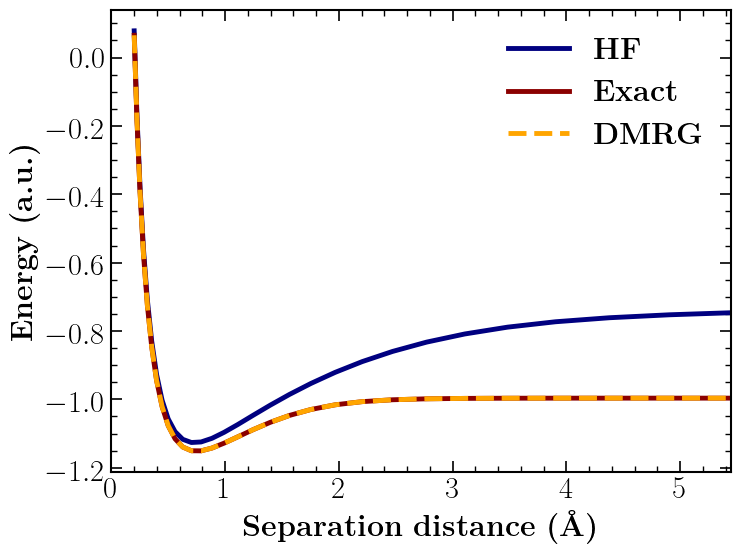

In [ ]:
enes_fci = np.load('FCI_enes_631G_h2.npy')
enes_hf = np.load('HF_enes_631G_h2.npy')
_enes_dmrg = np.load('DMRG_enes_631G_h2.npy')

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(separations, enes_hf, label=r'\textbf{HF}')
ax.plot(separations, enes_fci, label=r'\textbf{Exact}')
ax.plot(separations, _enes_dmrg, label=r'\textbf{DMRG}', ls='--')

ax.set_ylabel(r'\textbf{Energy (a.u.)}')
ax.set_xlabel(r'\textbf{Separation distance (Å)}')

ax.set_xlim(0,5.45)

plt.legend()
plt.show()

(Computed with the 6-31G basis-set) At small separations all methods overlap while as the separation increases HF rises too steeply as it cannot describe the situation with the two MOs approaching degeneracy. At small separations the energy difference between the two MOs increases drastically, due to the favourable screening by having electronic density betweent he two nuclei as well as the related increased kinetic energy due to the sharp node which means that the out-of-phase/antibonding orbital is much higher in energy, while the in phase decreases.

# H$_4$, hydrogen chain and orbital ordering

To see some more properties of DMRG we can look at a chain of four hydrogen, with a slightly longer separation in the middle. We start by running the ground state calculation like before.

In [131]:
E_FCI_4H = -2.18762272172627

mol_xyz = """4

H 0.000 0.000 0.000
H 0.000 0.000 1.000
H 0.000 0.000 2.300
H 0.000 0.000 3.300
"""

In [153]:
molecule = vlx.Molecule.read_xyz_string(mol_xyz)
basis_str = 'STO-3G'
basis = vlx.MolecularBasis.read(molecule, basis_str)
print(basis.info_str(basis_str))

                  Molecular Basis (STO-3G)                  

Basis: STO-3G                                               

  Atom Contracted GTOs           Primitive GTOs                

  H     (1S)                      (3S)                          

Contracted Basis Functions : 4                              
Primitive Basis Functions  : 12                             




In [154]:
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.ostream.mute()
scf_res = scf_drv.compute(molecule,basis)

In [155]:
orb_drv = vlx.OrbitalViewer()
orb_drv.plot(molecule, basis, scf_drv.mol_orbs)

Output()

Dropdown(description='Orbital:', index=1, options=(('  1 occ=2.000 ene=-0.568  (alpha HOMO-1)', 0), ('  2 occ=…

In [156]:
int_drv = dmrg.IntegralsDriver()
t_ij, v_ijkl = int_drv.get_transformed_integrals(molecule, basis, scf_res)

In [ ]:
nr_sites = 4
m_bonddim = 18

settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=m_bonddim)
mps_drv = dmrg.MpsDriver(settings)
mpo_drv = dmrg.MpoDriver(settings)

elec_mpo = mpo_drv.electronic_mpo(t_ij, v_ijkl)

mps_drv.initialize_random_mps()
mps_drv.canonical_form(0)
mps_drv.normalize()
mps = mps_drv.mps

sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)

In [161]:
E0, _mps = sweep_drv.compute(elec_mpo)

Sweep: 1
Energy after right sweep: -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Energy after left sweep : -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Sweep: 2
Energy after right sweep: -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Energy after left sweep : -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)


** Converged after 2 sweeps! **
Ground-state energy = -4.273547 a.u.



In [162]:
dmrg_ene = E0 + int_drv.nuc_repulsion_energy
print(f'Ex. - DMRG: {(E_FCI_4H - (dmrg_ene)):.2e}')

Ex. - DMRG: 5.77e-15


In [139]:
nr_up = mps_drv.get_expectation_value(mpo_drv.number_mpo('up'))
nr_dn = mps_drv.get_expectation_value(mpo_drv.number_mpo('down'))
print(f'Nr. spin up  : {nr_up:.3f}\nNr. spin down: {nr_dn:.3f}')
tot_nr = mps_drv.get_expectation_value(mpo_drv.total_number_mpo())
print(f'Total nr. of electrons: {tot_nr:.3f}')

Nr. spin up  : 2.000
Nr. spin down: 2.000
Total nr. of electrons: 4.000


In [140]:
nr_bonds = nr_sites - 1

entropy = [mps_drv.bipartite_entang_entropy(i) for i in range(3)]
print(f'Entanglement entropy at each bond: \nBond 0: {entropy[0]:.3f} \nBond 1: {entropy[1]:.3f} \nBond 2: {entropy[2]:.3f}')

Entanglement entropy at each bond: 
Bond 0: 0.278 
Bond 1: 0.398 
Bond 2: 0.258


The bipartite entanglement entropy is not basis independent, and since DMRG is most efficient when the entanglement is low a crucial factor when doing DMRG calculations is choosing a good order of the orbitals along the chain so that the entanglement does not need to propagate very far. One is furthermore strongly advised to use localized molecular orbitals as well, though for this simple example there is little to be gained from this.

We can see what happens if we change the orbital ordering to see if we can reduce the *maximal* bipartite entanglement entropy.

In [ ]:
# Permute the orbital ordering
perm_scf = scf_res.copy()
perm_scf['C_alpha'][:, [0,1,2,3]] = perm_scf['C_alpha'][:, [1,2,3,0]]

int_drv = dmrg.IntegralsDriver()
t_ij, v_ijkl = int_drv.get_transformed_integrals(molecule, basis, perm_scf)

settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=m_bonddim)
mps_drv = dmrg.MpsDriver(settings)
mpo_drv = dmrg.MpoDriver(settings)

elec_mpo = mpo_drv.electronic_mpo(t_ij, v_ijkl)

mps_drv.initialize_random_mps()
mps_drv.canonical_form(0)
mps_drv.normalize()
mps = mps_drv.mps

sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)

In [142]:
E0, _mps = sweep_drv.compute(elec_mpo)

Sweep: 1
Energy after right sweep: -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Energy after left sweep : -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Sweep: 2
Energy after right sweep: -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)

Energy after left sweep : -4.273547 a.u.
Discarded weight: max = 0.000e+00, mean = 0.000e+00 (worst bond: 0)


** Converged after 2 sweeps! **
Ground-state energy = -4.273547 a.u.



In [143]:
entropy_after_perm = [mps_drv.bipartite_entang_entropy(i) for i in range(3)]
print(f'Entanglement entropy at each bond: \nBond 0: {entropy_after_perm[0]:.3f} \nBond 1: {entropy_after_perm[1]:.3f} \nBond 2: {entropy_after_perm[2]:.3f}')

Entanglement entropy at each bond: 
Bond 0: 0.352 
Bond 1: 0.311 
Bond 2: 0.278


We see a decrease in the maximal value, which really is the bottleneck for DMRG. This example is a bit too simple to enable a significant reduction in the required bond dimension, but for production-type calculations this can really enable a calculation. These entanglement measures can also be used for active space selection. 

However, it might seem circular in that to increase the efficiency one needs to run a full calculation first, but due to entanglement measures converging *faster* than the energy, one can, and usually do so-called warm-up runs with a low bond dimension to set the orbital order.

# MPO formalism

A nice property of the MPO formalism is that new operators are straightforward to construct, and once they are obtained as MPOs the ground state can be found just as before. They can always be formed in a *naive* way in by just adding operators on the diagonal, though, in this case the MPO bond dimension increases rapidly with system size ($\mathcal{O}( L^4)$). The crux then is finding efficient MPO representations. For instance sums of local operators such as the chemical potential, or number operator, can be written with a constant bond dimension of 2, as per:

$$ \lambda \sum_i \hat{O}_i = \lambda \, \begin{pmatrix} I_0 & \hat{O}_0 \end{pmatrix} \left[ \prod_{i=1}^{L-2} \begin{pmatrix} I_i & \hat{O}_i \\ 0 & I_i \end{pmatrix} \right] \begin{pmatrix} \hat{O}_{L-1}\\ I_{L-1} \end{pmatrix} $$

Unfortunately, due to the complex four-body terms in the electronic Hamiltonian, there are no such nice forms for it. For the Hubbard model, though, (introduced in the next section) there is a form with a fixed bond dimension of 6, though for chains shorter than that, the naive implementation is faster.

# Hubbard model
$$ \hat{H} = -t \sum_{\sigma, i} \left[\hat{c}^\dagger_{i, \sigma} \hat{c}^{\vphantom{\dagger}}_{i+1, \sigma} + \hat{c}^\dagger_{i+1, \sigma} \hat{c}^{\vphantom{\dagger}}_{i, \sigma} \right] + U \sum_{i} \hat{n}_{i \uparrow} \hat{n}_{i \downarrow} - \mu  \sum_{i} \hat{N}_i  $$

The first term represents the kinetic/hopping term, while the term related to U represents on-site repulsion, while the chemical potential is here included to keep a fixed particle number. 
It should be noted that there is some instability of the DMRG solver for the Hubbard model, some bug in the implementation, though for all numerical tests performed so far it always converges to the exact solution so this *seems* like a formal problem for now, but this will be addressed.

In [150]:
# Set parameters
nr_sites = 4
max_bonddim = 2

# t=1, U=2, mu=1
hubb_ref_3site = -4.8200893743747875
hubb_ref_4site = -6.875942809005068
t = 1
U=2
mu=1

In [151]:
# Initialize the DMRG-drivers
settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=max_bonddim)
mps_drv = dmrg.MpsDriver(settings)
mpo_drv = dmrg.MpoDriver(settings)
sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)

In [ ]:
# Initialise the wavefunction/MPS
mps_drv.initialize_random_mps()
mps_drv.canonical_form(0)
mps_drv.normalize()
mps = mps_drv.mps

In [147]:
# Construct the operator/MPO
#hubbard_mpo = mpo_drv.hubbard_mpo(t=t, U=U, mu=mu)
hubbard_mpo = mpo_drv.hubbard_mpo_naive(t=t, U=U, mu=mu)

In [148]:
E0, mps = sweep_drv.compute(hubbard_mpo, allow_bond_growth=True)

Sweep: 1
Energy after right sweep: -5.691496 a.u.
Discarded weight: max = 1.681e-01, mean = 1.542e-01 (worst bond: 0)

Energy after left sweep : -5.756291 a.u.
Discarded weight: max = 1.462e-01, mean = 1.433e-01 (worst bond: 2)

**OBS** Large truncation error: Maximum bond dimension increased from 2 to 4

Sweep: 2
Energy after right sweep: -6.676140 a.u.
Discarded weight: max = 1.630e-02, mean = 5.433e-03 (worst bond: 1)

Energy after left sweep : -6.737834 a.u.
Discarded weight: max = 5.984e-02, mean = 1.995e-02 (worst bond: 1)

**OBS** Large truncation error: Maximum bond dimension increased from 4 to 6

Sweep: 3
Energy after right sweep: -6.829850 a.u.
Discarded weight: max = 1.753e-02, mean = 5.842e-03 (worst bond: 1)

Energy after left sweep : -6.829907 a.u.
Discarded weight: max = 1.753e-02, mean = 5.842e-03 (worst bond: 1)

**OBS** Large truncation error: Maximum bond dimension increased from 6 to 8

Sweep: 4
Energy after right sweep: -6.867802 a.u.
Discarded weight: max = 1.476

In [149]:
#print(f'{abs(E0 - hubb_ref_3site):.4e}')
print(f'{abs(E0 - hubb_ref_4site):.4e}')

3.5527e-15


In [ ]:
bdims_list = [i for i in range(2,18,2)]
bdims_list.insert(0,1)
enes = []
for m_bonddim in bdims_list:
    settings = dmrg.Settings(nr_sites=nr_sites, max_bond_dim=m_bonddim)
    mps_drv = dmrg.MpsDriver(settings)

    mps_drv.initialize_random_mps()
    mps_drv.canonical_form(0)
    mps_drv.normalize()
    mps = mps_drv.mps
    
    mpo_drv = dmrg.MpoDriver(settings)

    #mpo_drv.canonical_center = mps_drv.canonical_center
    mpo = mpo_drv.hubbard_mpo(t=1.0, U=2, mu=1)
    sweep_drv = dmrg.SweepDriver(settings, mps_drv=mps_drv, mpo_drv=mpo_drv)
    try:
        print(f'\nBOND-DIM: {m_bonddim}\n')
        E0, _mps = sweep_drv.compute(mpo, allow_bond_growth=False)
        enes.append(E0)
    except:
        print(f"Bond-dim {m_bonddim} didn't converge")


BOND-DIM: 1

Sweep: 1
Energy after right sweep: -4.139566 a.u.
Discarded weight: max = 5.941e-01, mean = 5.701e-01 (worst bond: 0)

Energy after left sweep : -4.002264 a.u.
Discarded weight: max = 6.071e-01, mean = 5.941e-01 (worst bond: 1)

**OBS** Large truncation error! Allowing for bond dimension growth is advised.

Sweep: 2
Energy after right sweep: -4.053074 a.u.
Discarded weight: max = 5.984e-01, mean = 5.868e-01 (worst bond: 0)

Energy after left sweep : -4.083021 a.u.
Discarded weight: max = 5.848e-01, mean = 5.796e-01 (worst bond: 2)

**OBS** Large truncation error! Allowing for bond dimension growth is advised.

Sweep: 3
Energy after right sweep: -4.147857 a.u.
Discarded weight: max = 5.826e-01, mean = 5.684e-01 (worst bond: 0)

Energy after left sweep : -3.966691 a.u.
Discarded weight: max = 6.123e-01, mean = 5.975e-01 (worst bond: 1)

**OBS** Large truncation error! Allowing for bond dimension growth is advised.

Sweep: 4
Energy after right sweep: -4.137975 a.u.
Discarded

In [61]:
enes = np.load('hubbard_5_site_energies.npy')
bdims_list = np.load('hubbard_5_site_bonds.npy')

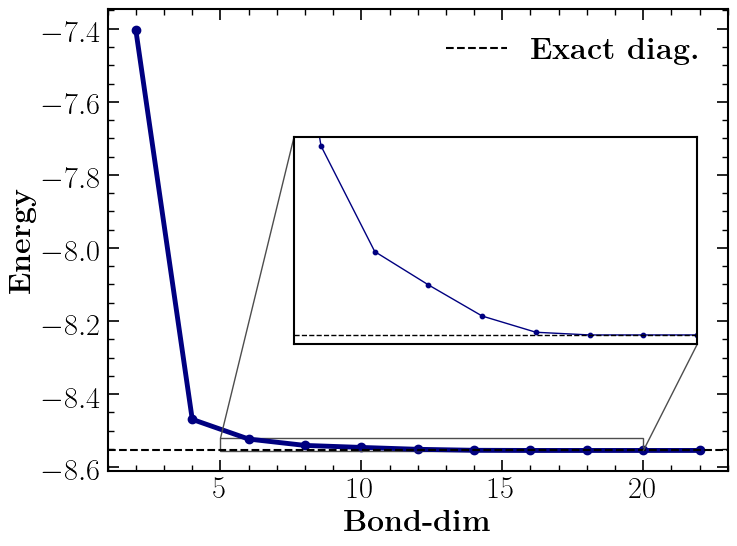

In [65]:
fig, ax = plt.subplots(figsize=(8,6))
offset=0
x = np.array(bdims_list)#[offset:])
y = np.array(enes)#[offset:])
exact = -8.55415139326221

ax.scatter(bdims_list, np.array(enes))# - exact)
ax.plot(bdims_list, np.array(enes))# - exact)
ax.axhline(exact, ls='--', label=r'\textbf{Exact diag.}', linewidth=1.5, color='k')
plt.legend()

axins = inset_axes(ax, width="65%", height="45%", loc="center right", borderpad=1.0)
axins.scatter(x, y, s=10)
axins.plot(x, y, lw=1.0)
axins.axhline(exact, ls='--', linewidth=1.0, color='k')

x1 = 5
x2 = 20
axins.set_xlim(x1, x2)

mask = (x >= x1) & (x <= x2)
ywin = y[mask]
pad = 0.05 * (ywin.max() - ywin.min() + 1e-12)
axins.set_ylim(ywin.min() - pad, ywin.max() + pad)

axins.set_xticks([])
axins.set_yticks([])
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.3")

ax.set_xlabel(r'\textbf{Bond-dim}')
ax.set_ylabel(r'\textbf{Energy}')

plt.show()

Here we can note a final feature of DMRG in that it converges monotonically to true ground state energy, as a function of the bond dimension, meaning extrapolations to the exact result is possible.

# End